# TS5: "Estimacion espectral: Ancho de banda de señales reales"

## Alumno: Suarez Lucila

Lo que hicimos fue estimar la densidad espectral de potencia (PSD) de tres tipos de señales reales, un registro electrocardiografico (ECG), una plestimografia (PPG) y dos muestras de audios. Para poder realizar la estimacion se nos pidio usar algun metodo visto en clase; en este trabajo se encontrara que se uso el metodo de Welch. 
Para terminar, se nos pidio estimar el ancho de banda de cada señal. 

El metodo Welch consiste en dividir en segmentos la señal, solapandolos al 50%, los ventanea, les calcula el periodgrama y los promedia. Al multiplicarlos por una ventana, baja la varianza y como consecuencia, se reduce la estimacion espectral. 

Se creo esta funcion para poder estimar el ancho de banda de las tres señales y poder hacer mas sencillo el codigo. La funcion recibe el vector de frecuencias f y la PSD (pxx) obetida con el metodo de Welch. La funcion "integra" la PSD para obtener la potencia acumulada en funcion de la frecuencia y la normaliza por la potencia total.

In [9]:
import numpy as np
from scipy import signal as sig
import matplotlib.pyplot as plt
import scipy.io as sio
from scipy.io.wavfile import write

def ancho_de_banda(f, pxx):
    df = f[1] - f[0]
    pot_acum = np.cumsum(pxx) * df        # potencia acumulada
    pot_acum = pot_acum / pot_acum[-1]    # normalizada a 1
    idx = np.searchsorted(pot_acum, 0.95)
    return f[idx]

K =  2 | BW95 =  22.93 Hz
K = 12 | BW95 =  22.00 Hz
K = 22 | BW95 =  22.74 Hz
K = 32 | BW95 =  21.34 Hz


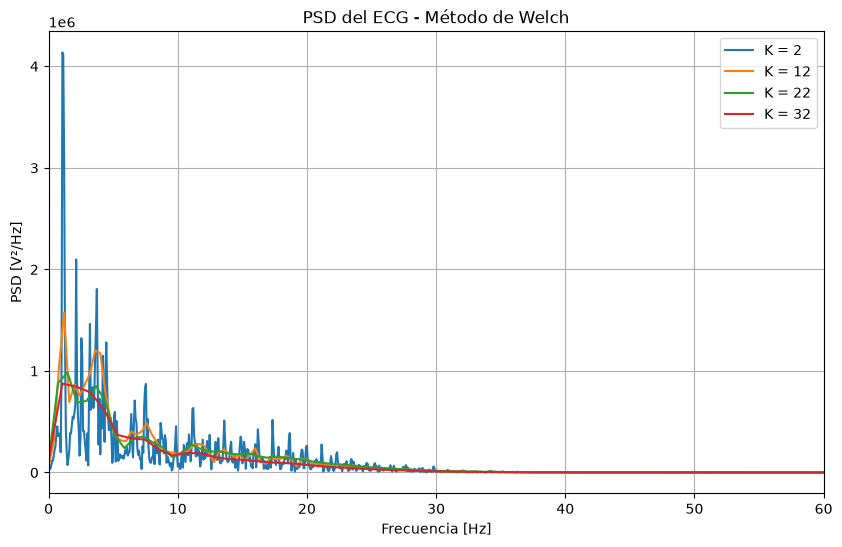

In [10]:
ecg_one_lead = np.load('ecg_sin_ruido.npy')
ecg_one_lead = ecg_one_lead - np.mean(ecg_one_lead) #saca la continua
fs_ecg = 1000 # Hz
k_vec=range(2,41, 10)
N=len(ecg_one_lead)
plt.figure(figsize=(10,6))

for K in k_vec:
    
    L = N // K
    
    f, pxx = sig.welch(
        ecg_one_lead,
        fs=fs_ecg,
        nperseg=L,
        noverlap=0
    )
    
    
    bw95 = ancho_de_banda(f, pxx)
    print(f'K = {K:2d} | BW95 = {bw95:6.2f} Hz')
    plt.plot(f, pxx, label=f'K = {K}')

plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [V²/Hz]')
plt.title('PSD del ECG - Método de Welch')
plt.grid()
plt.legend()
plt.xlim([0, 60])
plt.show()

Se observa que al aumentar la K, tenemos segmentos mas cortos, mas periodgramas para promediar y hay una curva mas suave (menor varianza), pero peor resolucion en frecuencia y picos mas anchos. Con respecto al ancho de banda, podemos decir que variar K no tuvo mucha relevancia al momento de calcular el ancho de banda. 

Muestras: 44919, duracion: 112.3 s


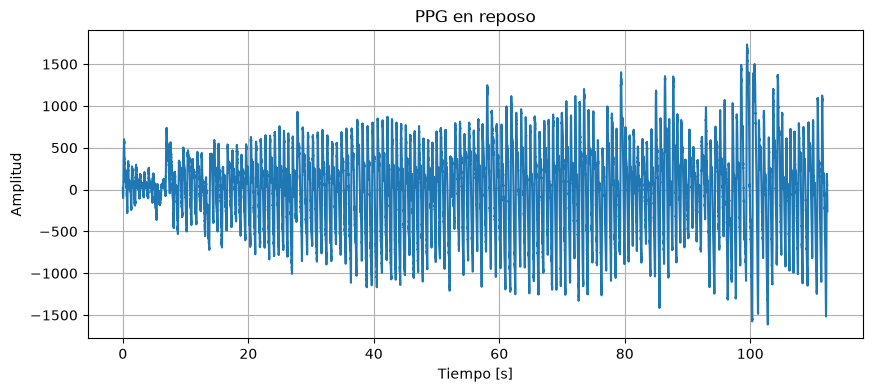

K =  2 | BW95 =   9.93 Hz
K = 12 | BW95 =   9.89 Hz
K = 22 | BW95 =   9.80 Hz
K = 32 | BW95 =   9.98 Hz


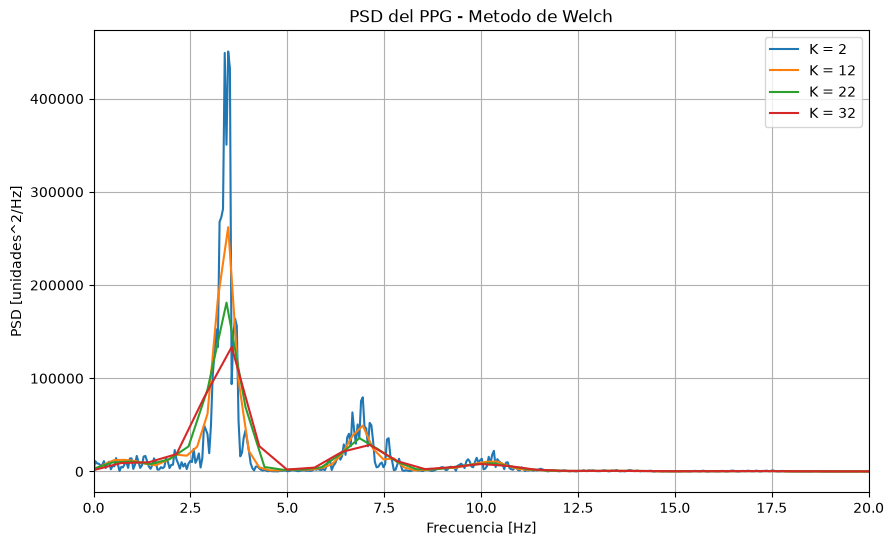

In [11]:
fs_ppg = 400 # Hz
ppg = np.load('ppg_sin_ruido.npy')
ppg = ppg - np.mean(ppg)
N_ppg=len(ppg)
t_ppg=np.arange(N_ppg)/fs_ppg

print(f'Muestras: {N_ppg}, duracion: {N_ppg/fs_ppg:.1f} s')

plt.figure(figsize=(10, 4))
plt.plot(t_ppg, ppg)
plt.xlabel('Tiempo [s]')
plt.ylabel('Amplitud')
plt.title('PPG en reposo')
plt.grid(True)
plt.show()

ppg_c=ppg-np.mean(ppg) #sacar la continua

plt.figure(figsize=(10, 6))
for K in k_vec:
    
    L = N_ppg // K
    
    f, pxx = sig.welch(
        ppg_c,
        fs=fs_ecg,
        nperseg=L,
        noverlap=L//2)
    
    bw95 = ancho_de_banda(f, pxx)
    print(f'K = {K:2d} | BW95 = {bw95:6.2f} Hz')
    plt.plot(f, pxx, label=f'K = {K}')
    
plt.xlabel('Frecuencia [Hz]')
plt.ylabel('PSD [unidades^2/Hz]')
plt.title('PSD del PPG - Metodo de Welch')
plt.grid(True)
plt.legend()
plt.xlim([0, 20])
plt.show()

El PPG presenta una ancho de banda menor que el ECG, lo cual sucede al PPG ser una señal mas suave. Ademas, sus valores resultan mas estables frente a K. 


la cucaracha.wav | fs = 48000 Hz | duración = 3.0 s
   frecuencia del pico = 1056.0 Hz
K = 12 | BW95 =  1516.00 Hz
   frecuencia del pico = 1056.1 Hz
K = 22 | BW95 =  1488.77 Hz
   frecuencia del pico = 1056.0 Hz
K = 32 | BW95 =  1482.67 Hz


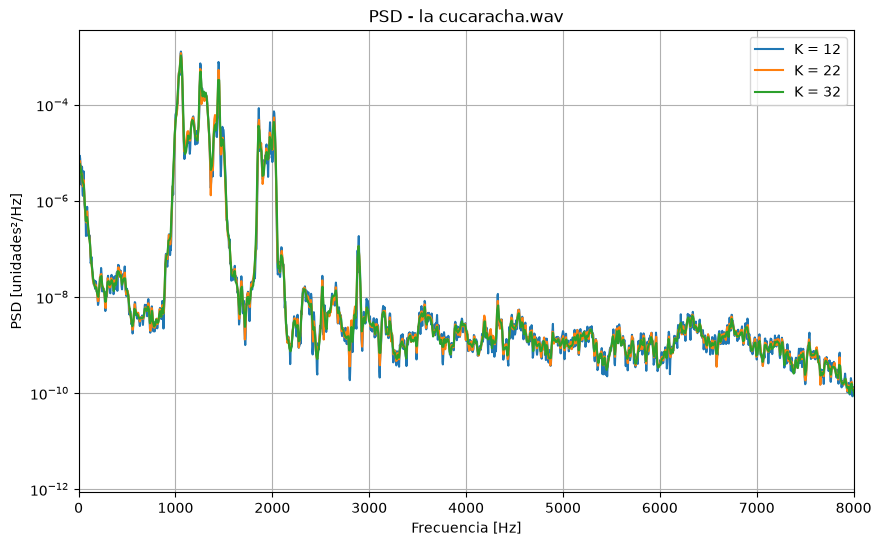


silbido.wav | fs = 48000 Hz | duración = 3.0 s
   frecuencia del pico = 6236.0 Hz
K = 12 | BW95 =  6308.00 Hz
   frecuencia del pico = 6233.8 Hz
K = 22 | BW95 =  6270.44 Hz
   frecuencia del pico = 6229.3 Hz
K = 32 | BW95 =  6293.33 Hz


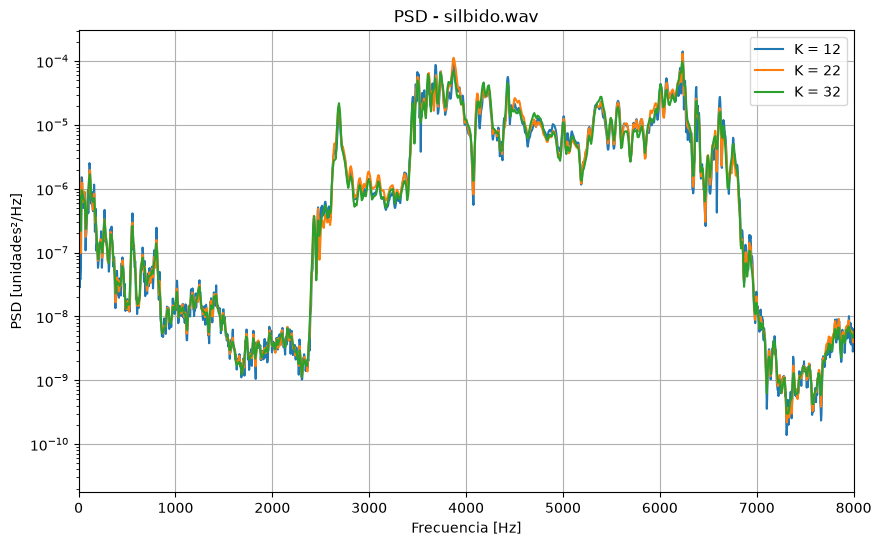

In [12]:
archivos = ['la cucaracha.wav', 'silbido.wav']   # después sumamos los de voz

for nombre in archivos:
    fs_audio, wav_data = sio.wavfile.read(nombre)

    x = wav_data.astype(float)
    if x.ndim > 1:
        x = x[:, 0]
    x = x - np.mean(x)
    x = x / np.max(np.abs(x))

    print(f'\n{nombre} | fs = {fs_audio} Hz | duración = {len(x)/fs_audio:.1f} s')

    plt.figure(figsize=(10, 6))
    for K in [12, 22, 32]:
        L = len(x) // K
        f, pxx = sig.welch(x, fs=fs_audio, nperseg=L, noverlap=L//2)
        
        f_pico = f[np.argmax(pxx)]
        print(f'   frecuencia del pico = {f_pico:.1f} Hz')

        bw95 = ancho_de_banda(f, pxx)
        print(f'K = {K:2d} | BW95 = {bw95:8.2f} Hz')
        plt.semilogy(f, pxx, label=f'K = {K}')

    plt.xlabel('Frecuencia [Hz]')
    plt.ylabel('PSD [unidades²/Hz]')
    plt.title(f'PSD - {nombre}')
    plt.grid(True)
    plt.legend()
    plt.xlim([0, 8000])
    plt.show()

Los registros de audio presentan un mayor ancho de banda que las dos señales anteriores. Entre ellos, el silbido resulta mayor que la "cucaracha". Esto se debe a que su frecuencia predominante es mas alta. 

Se estimo la PSD de cada señal con el metodo de Welch y se calculo el ancho de banda. Se observo que el parametro K modifica la varianza y la resolucion espectral, pero no el ancho de banda. Las señales biomedicas presentaron anchos de banda menores que las señales de audio. 